# Análisis Exploratorio de Datos: anuncios de vehículos usados

## Objetivo
Analizar el conjunto de datos `vehicles_us.csv` para evaluar su calidad, estudiar la distribución de las variables y explorar qué características se relacionan con el precio de los vehículos.

## Descripción del conjunto de datos
Cada fila representa un anuncio de venta. Las variables principales son: precio, año del modelo, modelo, condición, cilindros, combustible, odómetro, transmisión, tipo de vehículo, color, tracción 4x4, fecha de publicación y días que el anuncio permaneció publicado.

## Preguntas de análisis
1. ¿Cómo se distribuyen el precio, el kilometraje y los días publicados?
2. ¿Qué tipos y condiciones de vehículos son más frecuentes?
3. ¿Cómo se relacionan el precio con la antigüedad, el kilometraje, la condición y el tipo?
4. ¿Qué problemas de calidad deben atenderse antes de un modelo predictivo?

> **Enfoque:** el análisis usa técnicas de nivel principiante-intermedio y conserva una copia del dataset original.

In [7]:
# Librerías para manipulación y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RUTA_DATOS = "C:/OD/OneDrive - OHLAGROUP/Desktop/Jonathan Miranda/PERSONAL/TRIPLETEN/Proyectos/Sprint 7/Proyecto_S7/vehicles_us.csv"

## 1. Carga y exploración inicial

In [8]:
# Carga del archivo y vista preliminar
df = pd.read_csv(RUTA_DATOS)
display(df.head())
print(f"Dimensiones: {df.shape[0]:,} filas y {df.shape[1]} columnas")

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
0,9400,"2,011.00",bmw x5,good,6.00,gas,"145,000.00",automatic,SUV,NaN,1.00,2018-06-23,19
1,25500,NaN,ford f-150,good,6.00,gas,"88,705.00",automatic,pickup,white,1.00,2018-10-19,50
2,5500,"2,013.00",hyundai sonata,like new,4.00,gas,"110,000.00",automatic,sedan,red,NaN,2019-02-07,79
3,1500,"2,003.00",ford f-150,fair,8.00,gas,NaN,automatic,pickup,NaN,NaN,2019-03-22,9
4,14900,"2,017.00",chrysler 200,excellent,4.00,gas,"80,903.00",automatic,sedan,black,NaN,2019-04-02,28


Dimensiones: 51,525 filas y 13 columnas


**Interpretación:** la vista inicial permite confirmar que cada fila corresponde a un anuncio y que las columnas coinciden con la descripción esperada. Las dimensiones indican que existe suficiente información para comparar grupos y distribuciones.

In [9]:
# Tipos de datos e información general
print("Tipos de datos:")
display(df.dtypes.to_frame("tipo"))
print("\nResumen de .info():")
df.info()

Tipos de datos:


,tipo
price,int64
model_year,float64
model,str
condition,str
cylinders,float64
fuel,str
odometer,float64
transmission,str
type,str
paint_color,str



Resumen de .info():
<class 'pandas.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  str    
 3   condition     51525 non-null  str    
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  str    
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  str    
 8   type          51525 non-null  str    
 9   paint_color   42258 non-null  str    
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  str    
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 7.7 MB


**Interpretación:** `date_posted` se carga inicialmente como texto y debe convertirse a fecha. Algunas columnas numéricas contienen menos registros no nulos que el total, lo que confirma la presencia de datos faltantes.

In [10]:
# Estadísticas descriptivas de variables numéricas y categóricas
display(df.describe(include="number").T)
display(df.describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
price,"51,525.00","12,132.46","10,040.80",1.00,"5,000.00","9,000.00","16,839.00","375,000.00"
model_year,"47,906.00","2,009.75",6.28,"1,908.00","2,006.00","2,011.00","2,014.00","2,019.00"
cylinders,"46,265.00",6.13,1.66,3.00,4.00,6.00,8.00,12.00
odometer,"43,633.00","115,553.46","65,094.61",0.00,"70,000.00","113,000.00","155,000.00","990,000.00"
is_4wd,"25,572.00",1.00,0.00,1.00,1.00,1.00,1.00,1.00
days_listed,"51,525.00",39.55,28.20,0.00,19.00,33.00,53.00,271.00


C:\Users\jonathan.miranda\AppData\Local\Temp\ipykernel_10032\2975356076.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
model,51525,100,ford f-150,2796
condition,51525,6,excellent,24773
fuel,51525,5,gas,47288
transmission,51525,3,automatic,46902
type,51525,13,SUV,12405
paint_color,42258,12,white,10029
date_posted,51525,354,2019-03-17,186


**Interpretación:** las diferencias entre medias, medianas y máximos muestran posibles asimetrías y valores extremos, especialmente en precio y odómetro. En las variables categóricas se observan categorías dominantes que conviene comparar sin asumir causalidad.

In [11]:
# Diagnóstico de valores faltantes y duplicados
faltantes = (df.isna().sum().to_frame("cantidad")
             .assign(porcentaje=lambda x: x["cantidad"] / len(df) * 100)
             .sort_values("cantidad", ascending=False))
display(faltantes[faltantes["cantidad"] > 0])
print(f"Duplicados exactos: {df.duplicated().sum():,}")

,cantidad,porcentaje
is_4wd,25953,50.37
paint_color,9267,17.99
odometer,7892,15.32
cylinders,5260,10.21
model_year,3619,7.02


Duplicados exactos: 0


**Interpretación:** `is_4wd`, `paint_color`, `odometer`, `cylinders` y `model_year` requieren tratamiento. Los faltantes no deben rellenarse todos con una única regla, porque cada variable representa información diferente.

## 2. Limpieza y preparación de datos

In [12]:
# Crear una copia para no modificar los datos originales
df_clean = df.copy()

# Estandarizar encabezados y limpiar espacios en textos
df_clean.columns = df_clean.columns.str.strip().str.lower()
columnas_texto = df_clean.select_dtypes(include="object").columns
for columna in columnas_texto:
    df_clean[columna] = df_clean[columna].str.strip().str.lower()

# Convertir la fecha; errors="coerce" transforma fechas inválidas en NaT
df_clean["date_posted"] = pd.to_datetime(df_clean["date_posted"], errors="coerce")

print("Fechas inválidas después de convertir:", df_clean["date_posted"].isna().sum())
print("Rango de fechas:", df_clean["date_posted"].min().date(), "a", df_clean["date_posted"].max().date())

C:\Users\jonathan.miranda\AppData\Local\Temp\ipykernel_10032\4228557632.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df_clean.select_dtypes(include="object").columns


Fechas inválidas después de convertir: 0
Rango de fechas: 2018-05-01 a 2019-04-19


**Problema:** los textos pueden contener espacios o diferencias de mayúsculas, y la fecha estaba almacenada como texto.  
**Solución:** se normalizaron textos y se convirtió `date_posted` con validación.  
**Motivo:** esto evita categorías duplicadas artificialmente y permite crear variables temporales.

In [13]:
# Eliminar duplicados exactos, si existen
filas_antes = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
print(f"Duplicados eliminados: {filas_antes - len(df_clean):,}")

# Tracción 4x4: en este dataset, 1 indica 4x4 y el faltante se interpreta como 0
# Se conserva una bandera que permite rastrear qué valores fueron imputados.
df_clean["is_4wd_imputed"] = df_clean["is_4wd"].isna()
df_clean["is_4wd"] = df_clean["is_4wd"].fillna(0).astype("int8")

# Color faltante: categoría explícita, sin inventar un color
df_clean["paint_color"] = df_clean["paint_color"].fillna("desconocido")

Duplicados eliminados: 0


**Problema:** los duplicados podrían sobre representar anuncios; los faltantes de color no permiten inferir un valor real. En `is_4wd`, el dataset utiliza 1 para indicar tracción 4x4 y deja vacíos los demás casos.  
**Solución:** se eliminan duplicados exactos, el color se marca como `desconocido` y `is_4wd` se completa con 0, conservando una bandera de imputación.  
**Motivo:** se mantiene la trazabilidad sin inventar categorías observadas.

In [14]:
# Imputación contextual, usando información de vehículos similares
# 1) Año: mediana por modelo; si no alcanza, mediana global
mediana_anio_modelo = df_clean.groupby("model")["model_year"].transform("median")
df_clean["model_year"] = df_clean["model_year"].fillna(mediana_anio_modelo)
df_clean["model_year"] = df_clean["model_year"].fillna(df_clean["model_year"].median()).round().astype("int16")

# 2) Cilindros: moda por modelo; si no existe, moda global
moda_cilindros_modelo = df_clean.groupby("model")["cylinders"].transform(
    lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan
)
df_clean["cylinders"] = df_clean["cylinders"].fillna(moda_cilindros_modelo)
df_clean["cylinders"] = df_clean["cylinders"].fillna(df_clean["cylinders"].mode().iloc[0]).astype("int8")

# 3) Odómetro: mediana por año y condición; respaldo con mediana por año y global
mediana_odometro_grupo = df_clean.groupby(["model_year", "condition"])["odometer"].transform("median")
mediana_odometro_anio = df_clean.groupby("model_year")["odometer"].transform("median")
df_clean["odometer"] = df_clean["odometer"].fillna(mediana_odometro_grupo)
df_clean["odometer"] = df_clean["odometer"].fillna(mediana_odometro_anio)
df_clean["odometer"] = df_clean["odometer"].fillna(df_clean["odometer"].median())

print("Valores faltantes restantes:", int(df_clean.isna().sum().sum()))

Valores faltantes restantes: 0


**Problema:** año, cilindros y odómetro tienen faltantes, pero una mediana global ignoraría diferencias entre modelos.  
**Solución:** se usan medianas o modas de grupos comparables y un valor global únicamente como respaldo.  
**Motivo:** es un método sencillo, reproducible y más contextual que una imputación única.

In [15]:
# Validaciones básicas de formato y creación de variables útiles
anio_publicacion = df_clean["date_posted"].dt.year

df_clean["vehicle_age"] = (anio_publicacion - df_clean["model_year"]).clip(lower=0)
df_clean["posting_year"] = anio_publicacion
df_clean["posting_month"] = df_clean["date_posted"].dt.month

validaciones = pd.Series({
    "precios_no_positivos": (df_clean["price"] <= 0).sum(),
    "odometros_negativos": (df_clean["odometer"] < 0).sum(),
    "dias_negativos": (df_clean["days_listed"] < 0).sum(),
    "años_posteriores_publicación": (df_clean["model_year"] > anio_publicacion).sum(),
    "fechas_invalidas": df_clean["date_posted"].isna().sum()
})
display(validaciones.to_frame("cantidad"))

,cantidad
precios_no_positivos,0
odometros_negativos,0
dias_negativos,0
años_posteriores_publicación,0
fechas_invalidas,0


**Interpretación:** las validaciones buscan valores imposibles, no solamente extremos. Se crea `vehicle_age` porque la antigüedad al momento del anuncio es más interpretable que el año por sí solo.

In [16]:
# Detección de valores atípicos con el método del rango intercuartílico (IQR)
def limites_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

resumen_outliers = []
mascaras_validas = pd.Series(True, index=df_clean.index)
for columna in ["price", "odometer", "days_listed"]:
    inferior, superior = limites_iqr(df_clean[columna])
    mascara_outlier = ~df_clean[columna].between(max(0, inferior), superior)
    resumen_outliers.append({"variable": columna, "límite_inferior": max(0, inferior),
                             "límite_superior": superior, "atípicos": mascara_outlier.sum(),
                             "porcentaje": mascara_outlier.mean() * 100})
    mascaras_validas &= ~mascara_outlier

display(pd.DataFrame(resumen_outliers))

# No se eliminan del dataset limpio. Solo se crea una vista sin extremos para algunos gráficos.
df_eda = df_clean.loc[mascaras_validas].copy()
print(f"Registros originales limpios: {len(df_clean):,}")
print(f"Registros en vista gráfica sin extremos simultáneos: {len(df_eda):,}")

,variable,límite_inferior,límite_superior,atípicos,porcentaje
0,price,0,"34,597.50",1646,3.19
1,odometer,0,"269,646.50",692,1.34
2,days_listed,0,104.00,1618,3.14


Registros originales limpios: 51,525
Registros en vista gráfica sin extremos simultáneos: 47,646


**Problema:** los extremos pueden comprimir los gráficos y ocultar el comportamiento de la mayoría.  
**Solución:** se identifican con IQR y se crea `df_eda` únicamente para visualización.  
**Motivo:** no se eliminan de forma definitiva, porque un precio alto o un kilometraje elevado puede ser real. Para modelado, deberán revisarse con reglas de negocio.

## 3. Análisis Exploratorio de Datos

### 3.1 Estadística descriptiva

In [17]:
# Resumen solicitado: media, mediana, moda, mínimos, máximos, desviación y cuartiles
numericas = ["price", "model_year", "cylinders", "odometer", "days_listed", "vehicle_age"]
resumen = pd.DataFrame(index=numericas)
resumen["media"] = df_clean[numericas].mean()
resumen["mediana"] = df_clean[numericas].median()
resumen["moda"] = [df_clean[c].mode().iloc[0] for c in numericas]
resumen["mínimo"] = df_clean[numericas].min()
resumen["q1"] = df_clean[numericas].quantile(0.25)
resumen["q3"] = df_clean[numericas].quantile(0.75)
resumen["máximo"] = df_clean[numericas].max()
resumen["desv_estándar"] = df_clean[numericas].std()
display(resumen)

,media,mediana,moda,mínimo,q1,q3,máximo,desv_estándar
price,"12,132.46","9,000.00",1.00,1.00,"5,000.00","16,839.00","375,000.00","10,040.80"
model_year,"2,009.79","2,011.00","2,011.00","1,908.00","2,007.00","2,014.00","2,019.00",6.10
cylinders,6.12,6.00,8.00,3.00,4.00,8.00,12.00,1.66
odometer,"115,235.73","114,816.00","97,078.00",0.00,"73,159.00","151,754.00","990,000.00","62,207.19"
days_listed,39.55,33.00,18.00,0.00,19.00,53.00,271.00,28.20
vehicle_age,8.51,8.00,7.00,0.00,4.00,12.00,110.00,6.11


**Interpretación:** cuando la media supera claramente a la mediana, la distribución suele tener una cola hacia valores altos. Los cuartiles describen el 50% central y son menos sensibles a extremos que el mínimo y el máximo.

### 3.2 Análisis univariado

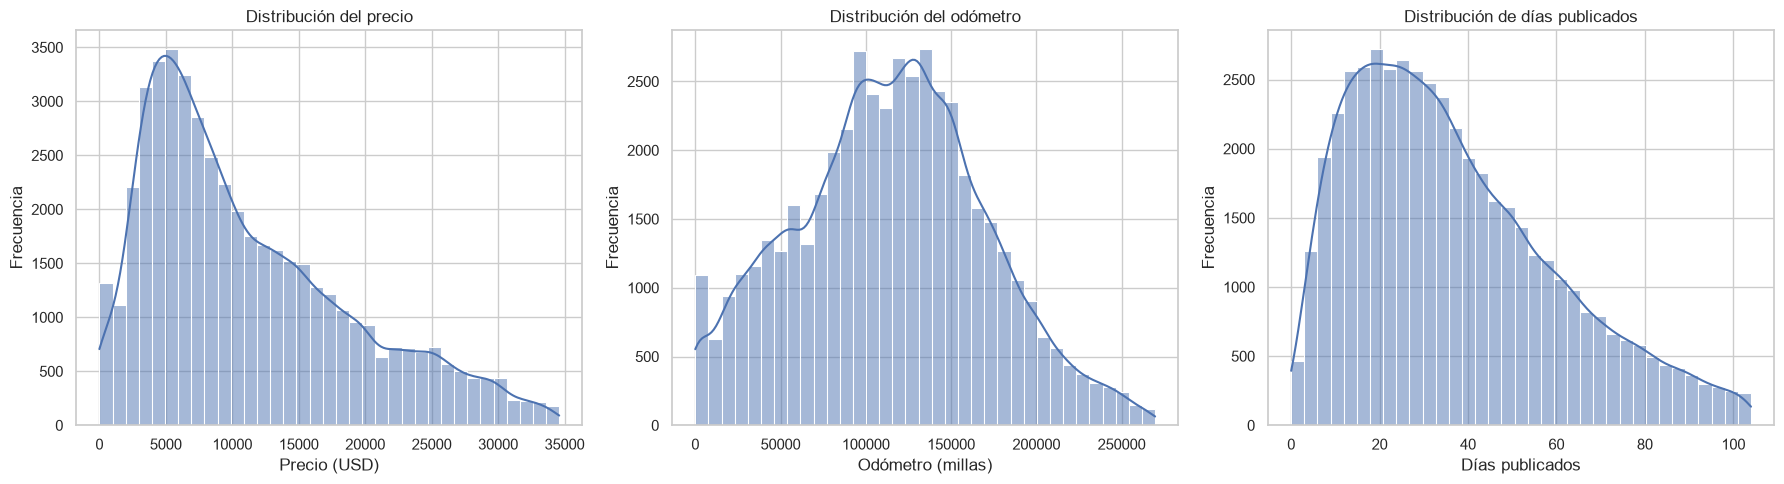

In [18]:
# Histogramas de precio, odómetro y días publicados usando la vista sin extremos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, columna, titulo, etiqueta in zip(
    axes,
    ["price", "odometer", "days_listed"],
    ["Distribución del precio", "Distribución del odómetro", "Distribución de días publicados"],
    ["Precio (USD)", "Odómetro (millas)", "Días publicados"]):
    sns.histplot(data=df_eda, x=columna, bins=35, kde=True, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

**Interpretación:** los histogramas muestran la forma y concentración de cada variable después de apartar extremos solo para facilitar la lectura. Una cola derecha indica que existen pocos anuncios con valores mucho mayores que la mayoría.

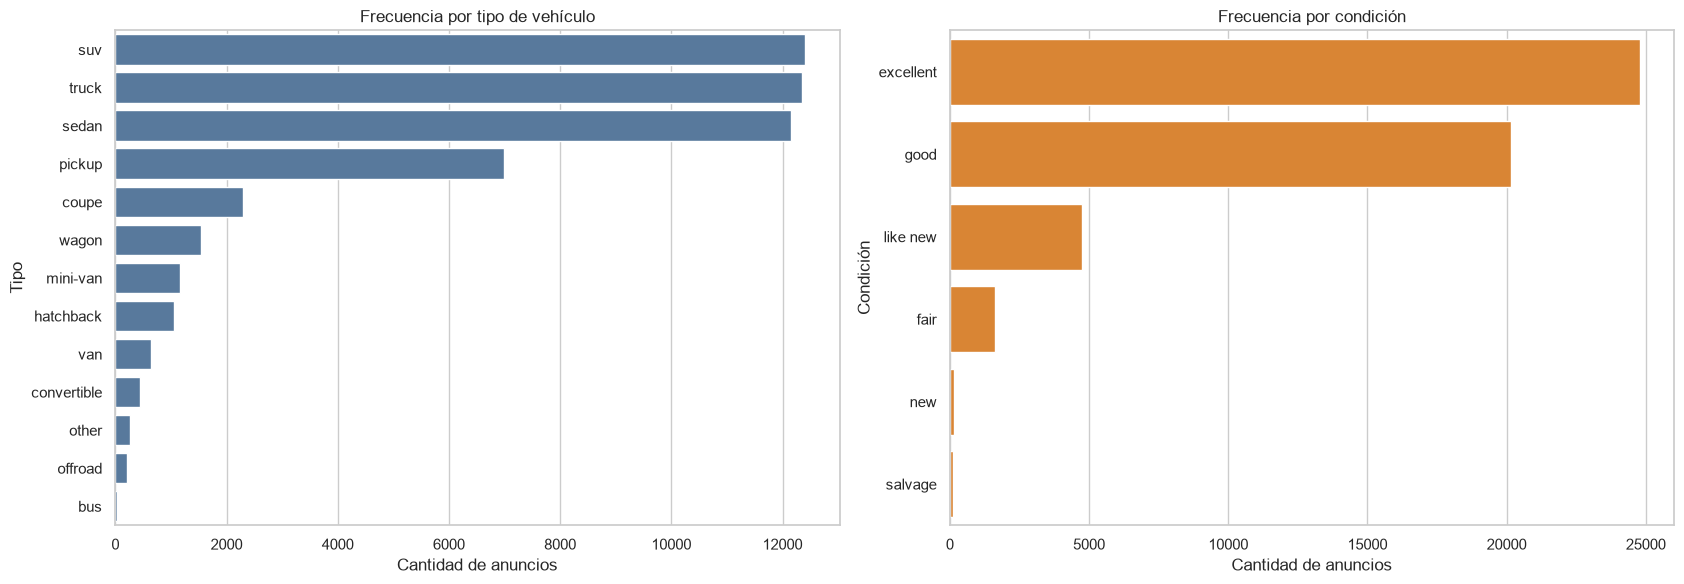

In [19]:
# Frecuencias de variables categóricas
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
orden_tipo = df_clean["type"].value_counts().index
orden_condicion = df_clean["condition"].value_counts().index
sns.countplot(data=df_clean, y="type", order=orden_tipo, ax=axes[0], color="#4C78A8")
axes[0].set_title("Frecuencia por tipo de vehículo")
axes[0].set_xlabel("Cantidad de anuncios")
axes[0].set_ylabel("Tipo")
sns.countplot(data=df_clean, y="condition", order=orden_condicion, ax=axes[1], color="#F58518")
axes[1].set_title("Frecuencia por condición")
axes[1].set_xlabel("Cantidad de anuncios")
axes[1].set_ylabel("Condición")
plt.tight_layout()
plt.show()

**Interpretación:** los gráficos de barras permiten identificar las categorías con mayor representación. Las categorías con pocos anuncios deben interpretarse con cautela al comparar precios, porque sus resultados son menos estables.

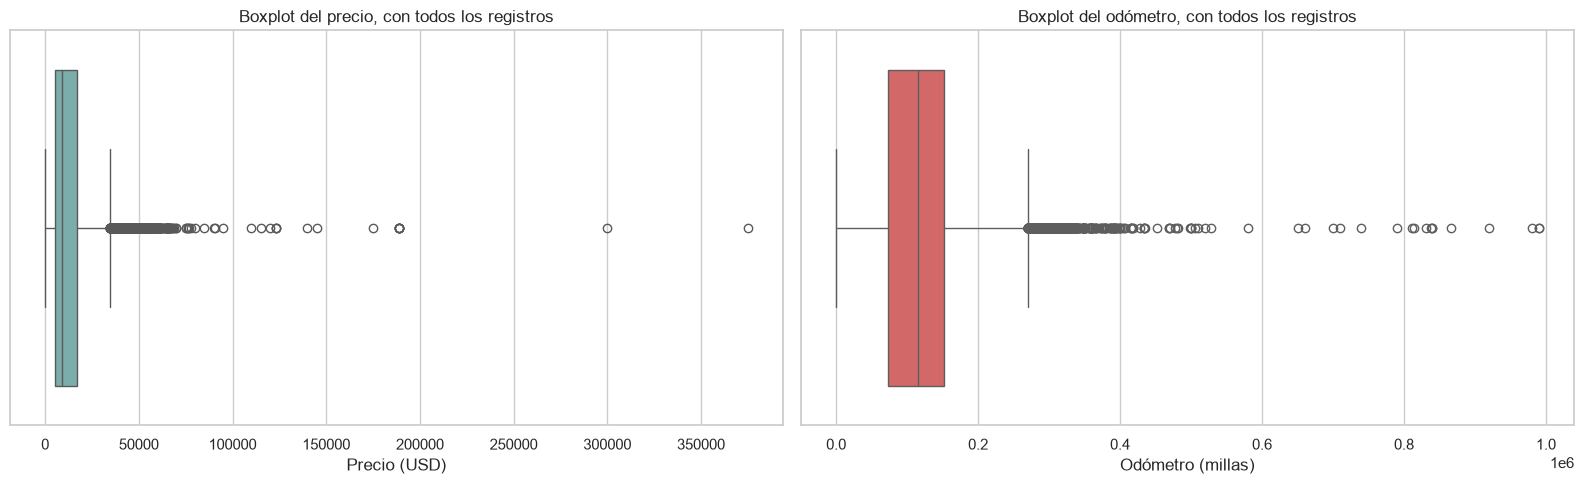

In [20]:
# Boxplots para revisar dispersión y posibles valores extremos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df_clean, x="price", ax=axes[0], color="#72B7B2")
axes[0].set_title("Boxplot del precio, con todos los registros")
axes[0].set_xlabel("Precio (USD)")
sns.boxplot(data=df_clean, x="odometer", ax=axes[1], color="#E45756")
axes[1].set_title("Boxplot del odómetro, con todos los registros")
axes[1].set_xlabel("Odómetro (millas)")
plt.tight_layout()
plt.show()

**Interpretación:** los puntos alejados del cuerpo principal confirman la presencia de observaciones atípicas. El boxplot ayuda a detectarlas, pero no demuestra que sean errores.

### 3.3 Análisis bivariado

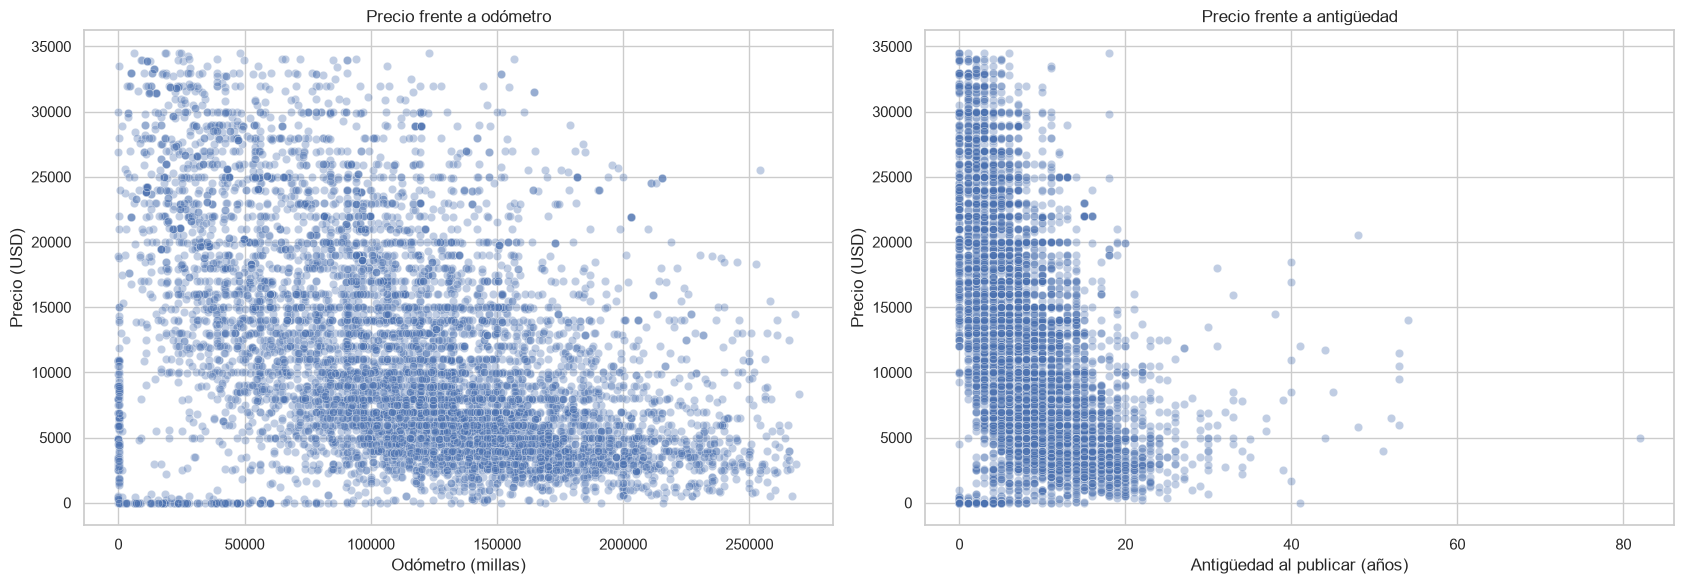

In [21]:
# Precio frente a odómetro y antigüedad; se toma una muestra para mejorar legibilidad
muestra = df_eda.sample(min(8000, len(df_eda)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.scatterplot(data=muestra, x="odometer", y="price", alpha=0.35, ax=axes[0])
axes[0].set_title("Precio frente a odómetro")
axes[0].set_xlabel("Odómetro (millas)")
axes[0].set_ylabel("Precio (USD)")
sns.scatterplot(data=muestra, x="vehicle_age", y="price", alpha=0.35, ax=axes[1])
axes[1].set_title("Precio frente a antigüedad")
axes[1].set_xlabel("Antigüedad al publicar (años)")
axes[1].set_ylabel("Precio (USD)")
plt.tight_layout()
plt.show()

**Interpretación:** una nube descendente sugiere que el precio tiende a disminuir al aumentar el kilometraje o la antigüedad. La dispersión muestra que estas variables no explican el precio por sí solas.

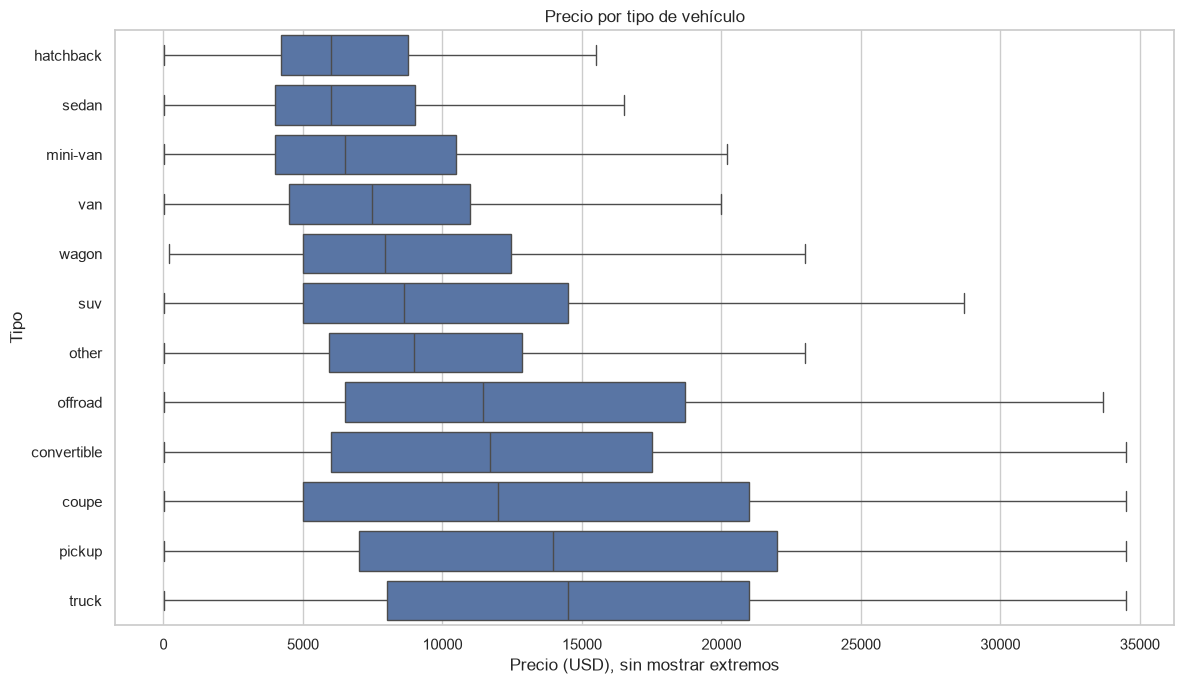

In [22]:
# Comparación de precio por tipo, solo para tipos con al menos 100 anuncios
conteos_tipo = df_clean["type"].value_counts()
tipos_suficientes = conteos_tipo[conteos_tipo >= 100].index
orden_precio_tipo = (df_eda[df_eda["type"].isin(tipos_suficientes)]
                     .groupby("type")["price"].median().sort_values().index)
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_eda[df_eda["type"].isin(tipos_suficientes)],
            y="type", x="price", order=orden_precio_tipo, showfliers=False)
plt.title("Precio por tipo de vehículo")
plt.xlabel("Precio (USD), sin mostrar extremos")
plt.ylabel("Tipo")
plt.tight_layout()
plt.show()

**Interpretación:** las medianas y cajas permiten comparar niveles de precio entre tipos sin depender demasiado de observaciones extremas. Las diferencias son asociaciones descriptivas y pueden reflejar año, modelo, condición u otras variables.

In [23]:
# Tabla resumen por condición
resumen_condicion = (df_clean.groupby("condition")
                     .agg(anuncios=("price", "size"),
                          precio_mediano=("price", "median"),
                          odometro_mediano=("odometer", "median"),
                          antiguedad_mediana=("vehicle_age", "median"))
                     .sort_values("precio_mediano", ascending=False))
display(resumen_condicion)

,anuncios,precio_mediano,odometro_mediano,antiguedad_mediana
condition,,,,
new,143,"21,999.00","7,500.00",0.00
like new,4742,"13,995.00","73,800.00",5.00
excellent,24773,"10,495.00","106,000.00",7.00
good,20145,"7,900.00","131,720.00",9.00
fair,1607,"2,500.00","182,000.00",15.00
salvage,115,"2,500.00","149,000.00",12.00


**Interpretación:** la tabla conjunta ayuda a comprobar si las diferencias de precio por condición también coinciden con diferencias de kilometraje o antigüedad. Esto evita atribuir todo el cambio a una sola variable.

### 3.4 Análisis de correlación

,price,model_year,cylinders,odometer,is_4wd,days_listed,vehicle_age
price,1.00,0.41,0.30,-0.43,0.32,-0.00,-0.41
model_year,0.41,1.00,-0.15,-0.49,0.04,-0.01,-1.00
cylinders,0.30,-0.15,1.00,0.09,0.41,0.00,0.15
odometer,-0.43,-0.49,0.09,1.00,0.03,0.00,0.49
is_4wd,0.32,0.04,0.41,0.03,1.00,0.00,-0.04
days_listed,-0.00,-0.01,0.00,0.00,0.00,1.00,0.01
vehicle_age,-0.41,-1.00,0.15,0.49,-0.04,0.01,1.00


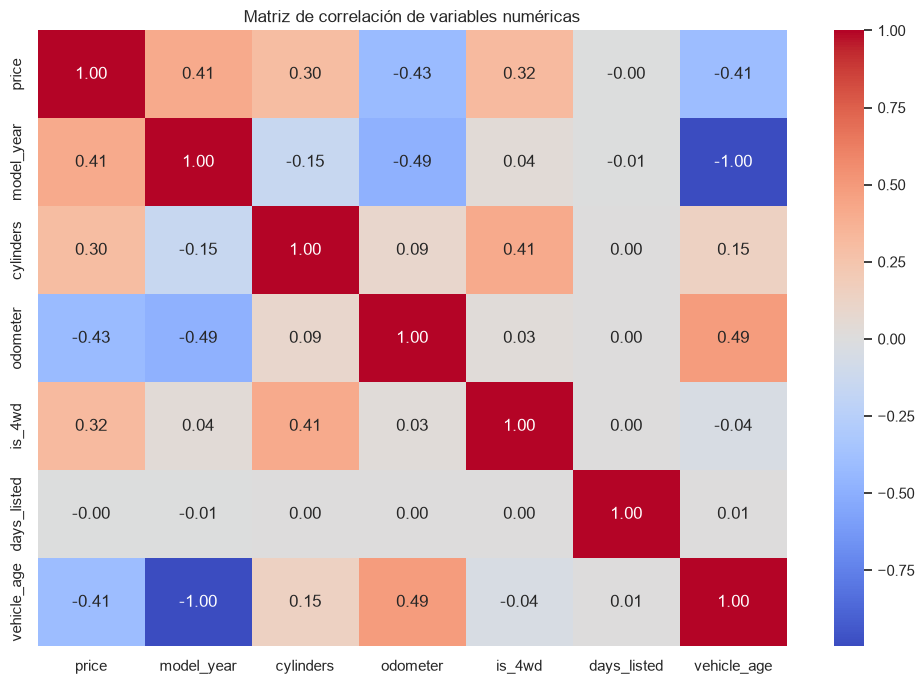

In [24]:
# Matriz de correlación de Pearson para variables numéricas
columnas_correlacion = ["price", "model_year", "cylinders", "odometer",
                        "is_4wd", "days_listed", "vehicle_age"]
correlacion = df_clean[columnas_correlacion].corr()
display(correlacion.round(2))

plt.figure(figsize=(10, 7))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

**Interpretación:** valores cercanos a 1 indican relación lineal positiva, cercanos a -1 relación lineal negativa y cercanos a 0 poca relación lineal. Correlación no implica causalidad. `model_year` y `vehicle_age` contienen información inversa y no deberían usarse juntas sin revisar multicolinealidad.

In [25]:
# Correlaciones con el precio, ordenadas por magnitud
correlacion_precio = (correlacion["price"].drop("price")
                      .sort_values(key=lambda s: s.abs(), ascending=False))
display(correlacion_precio.to_frame("correlación_con_precio"))
print("Mayor asociación positiva:", correlacion_precio.idxmax(), f"({correlacion_precio.max():.3f})")
print("Mayor asociación negativa:", correlacion_precio.idxmin(), f"({correlacion_precio.min():.3f})")

,correlación_con_precio
odometer,-0.43
model_year,0.41
vehicle_age,-0.41
is_4wd,0.32
cylinders,0.30
days_listed,-0.00


Mayor asociación positiva: model_year (0.413)
Mayor asociación negativa: odometer (-0.426)


**Interpretación:** el orden por magnitud ayuda a priorizar variables numéricas para análisis posteriores. Las variables categóricas importantes, como modelo, tipo o condición, no aparecen directamente en esta matriz y deberán codificarse antes de modelar.

## 4. Hallazgos principales

In [26]:
# Generar indicadores concretos para resumir resultados
precio_mediano = df_clean["price"].median()
tipo_frecuente = df_clean["type"].mode().iloc[0]
condicion_frecuente = df_clean["condition"].mode().iloc[0]
porcentaje_faltante_original = df.isna().mean().mul(100).sort_values(ascending=False)

print(f"Precio mediano: USD {precio_mediano:,.0f}")
print(f"Tipo más frecuente: {tipo_frecuente}")
print(f"Condición más frecuente: {condicion_frecuente}")
print(f"Variable con mayor porcentaje faltante original: {porcentaje_faltante_original.index[0]} "
      f"({porcentaje_faltante_original.iloc[0]:.1f}%)")
print(f"Correlación odómetro-precio: {correlacion.loc['odometer', 'price']:.3f}")
print(f"Correlación antigüedad-precio: {correlacion.loc['vehicle_age', 'price']:.3f}")

Precio mediano: USD 9,000
Tipo más frecuente: suv
Condición más frecuente: excellent
Variable con mayor porcentaje faltante original: is_4wd (50.4%)
Correlación odómetro-precio: -0.426
Correlación antigüedad-precio: -0.412


### Síntesis
- **Patrones:** el precio debe analizarse junto con antigüedad, kilometraje, tipo, condición y modelo.
- **Tendencias:** los scatterplots y correlaciones permiten observar si el precio tiende a reducirse al aumentar uso o antigüedad.
- **Comportamientos inusuales:** los extremos de precio, odómetro y días publicados requieren validación de negocio.
- **Variables influyentes:** las asociaciones numéricas más altas son candidatas, mientras que las variables categóricas deben evaluarse mediante codificación.
- **Impacto en modelos futuros:** la imputación, los extremos, las categorías poco frecuentes y la redundancia entre año y antigüedad pueden afectar resultados y métricas.

## 5. Conclusiones ejecutivas

El dataset es adecuado para análisis descriptivo y para preparar un modelo de precio, pero requiere limpieza documentada. Los principales retos de calidad son los valores faltantes en varias columnas y los valores extremos de precio, odómetro y duración del anuncio.

La imputación aplicada utiliza información de vehículos comparables y conserva una categoría explícita cuando no es razonable inferir el dato. Los extremos se mantienen en el conjunto limpio y solo se excluyen de una vista auxiliar para mejorar la lectura de ciertos gráficos.

### Limitaciones y riesgos
- El análisis es observacional: las relaciones encontradas no prueban causalidad.
- La imputación reduce faltantes, pero introduce estimaciones que deben considerarse en un modelo.
- Algunos precios u odómetros extremos pueden ser anuncios reales, errores o valores promocionales; falta una regla de negocio para distinguirlos.
- El modelo del vehículo es una variable de alta cardinalidad y necesitará preparación cuidadosa.

### Recomendaciones
1. Validar con conocimiento de negocio límites razonables de precio, año y odómetro.
2. Comparar modelos predictivos con y sin valores extremos.
3. Conservar indicadores de imputación para evaluar si los faltantes aportan señal.
4. Separar entrenamiento y prueba antes de ajustar transformaciones de modelado, para evitar fuga de información.
5. Evaluar MAE como métrica principal si el objetivo futuro es predecir precio, porque se interpreta en unidades monetarias.